
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


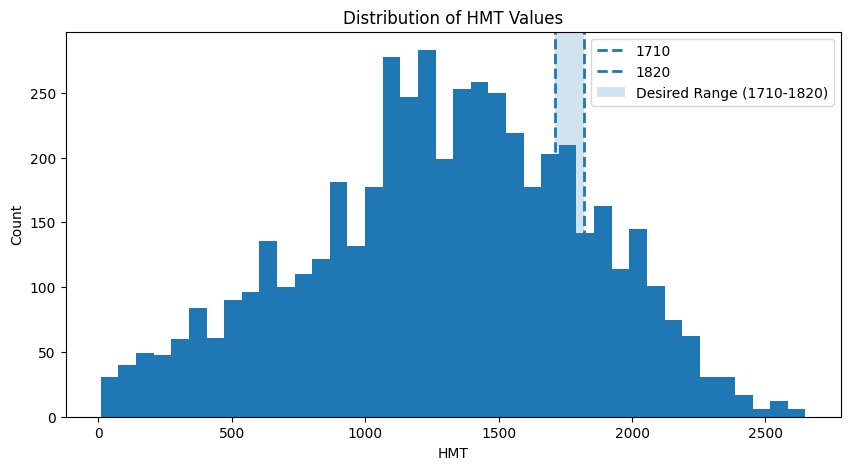

Total samples: 4999
Inside 1710-1820: 336
Percent inside: 6.72%


In [9]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

# Histogram of HMT
plt.figure(figsize=(10,5))

plt.hist(df["o_hmt"], bins=40)

# Desired operating range
plt.axvline(1710, linestyle="--", linewidth=2, label="1710")
plt.axvline(1820, linestyle="--", linewidth=2, label="1820")

# Shade target region
plt.axvspan(1710, 1820, alpha=0.2, label="Desired Range (1710-1820)")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Distribution of HMT Values")
plt.legend()

plt.show()

# Optional statistics
total = len(df)
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()

print(f"Total samples: {total}")
print(f"Inside 1710-1820: {inside}")
print(f"Percent inside: {100*inside/total:.2f}%")


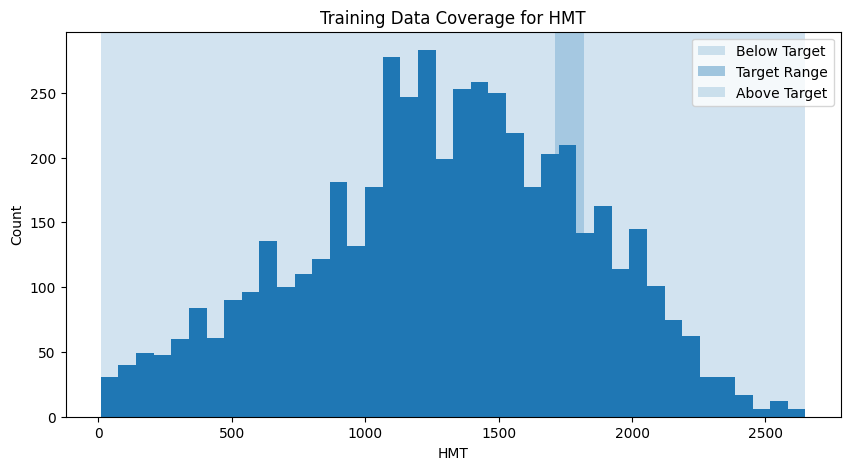

In [10]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

hmt = df["o_hmt"]

plt.figure(figsize=(10,5))
plt.hist(hmt, bins=40)

plt.axvspan(hmt.min(), 1710, alpha=0.2, label="Below Target")
plt.axvspan(1710, 1820, alpha=0.4, label="Target Range")
plt.axvspan(1820, hmt.max(), alpha=0.2, label="Above Target")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Training Data Coverage for HMT")
plt.legend()

plt.show()


In [11]:

below = (df["o_hmt"] < 1710).sum()
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()
above = (df["o_hmt"] > 1820).sum()

print("Below:", below, f"({100*below/len(df):.2f}%)")
print("Inside:", inside, f"({100*inside/len(df):.2f}%)")
print("Above:", above, f"({100*above/len(df):.2f}%)")


Below: 3830 (76.62%)
Inside: 336 (6.72%)
Above: 833 (16.66%)


In [12]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

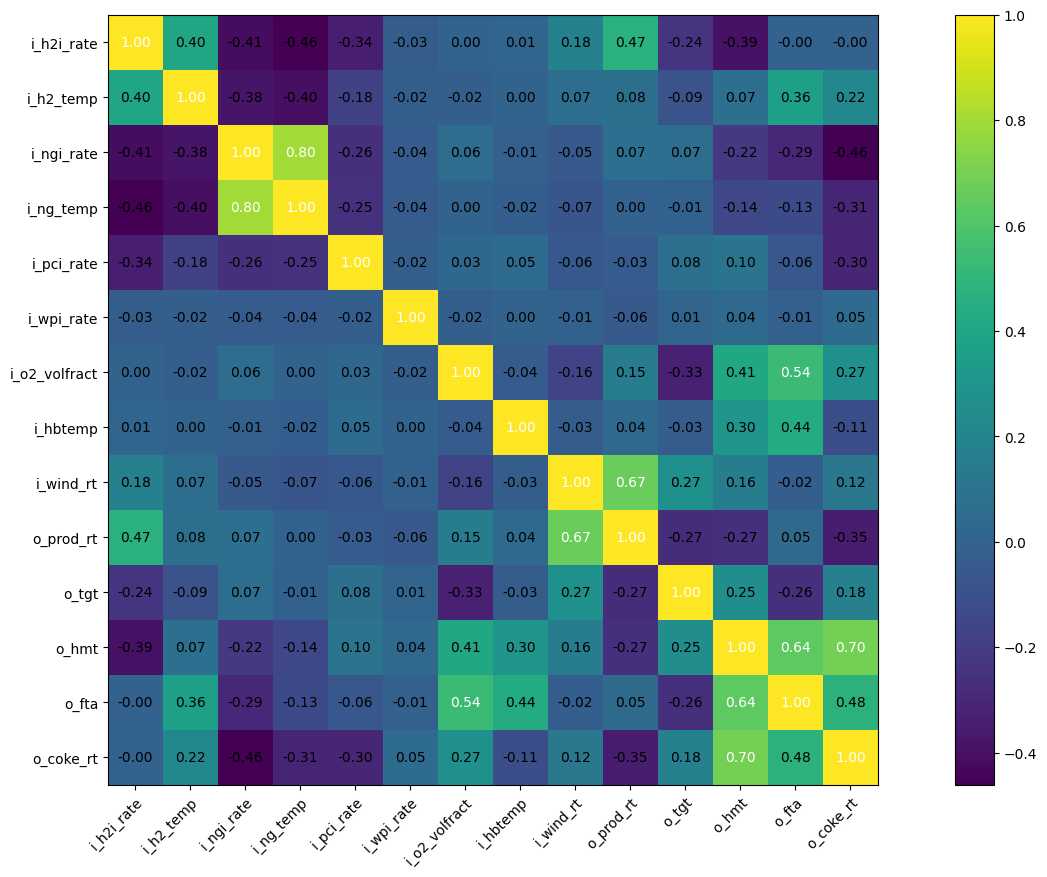

In [13]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [14]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [15]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [16]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [17]:

PDFshapingOBJ.random_seed = 42         ## int( random.random() * 100  )         ## defautl is 42


In [18]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [20]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [21]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [22]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [23]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [24]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [25]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [26]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [27]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [28]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.8501085638999939
100 ..... 0.187361940741539
200 ..... 0.23079127073287964
300 ..... 0.25591355562210083
400 ..... 0.24201105535030365
500 ..... 0.4005010426044464
600 ..... 0.21200934052467346
700 ..... 0.16746316850185394
800 ..... 0.4640129506587982
900 ..... 0.2655428647994995


In [29]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.5782, 1304.0294, 8451.0449, 2310.0466,  417.2470]])
y_deviations: tensor([[  50.0365,  519.6542, 1508.7687,  210.7183,   49.7243]])
x_means: tensor([[  12.3356,   19.4929,   40.9437,   25.6174,  415.3038, 1439.6299,
          198.7547]])
x_deviations: tensor([[ 15.2321,  46.1241,  46.5318,   3.3248, 271.8232, 158.0617,  26.5062]])


In [30]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.5417,  784.3752, 6942.2764, 2099.3284,  367.5227]])
tensor([[ 147.6147, 1823.6836, 9959.8135, 2520.7649,  466.9713]])


In [31]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.8965,  -26.6313,   -5.5881,   22.2926,  143.4807, 1281.5681,
          172.2484]])
tensor([[  27.5676,   65.6170,   87.4755,   28.9422,  687.1270, 1597.6917,
          225.2609]])


In [32]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Costs




## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')




In [33]:



def cost_func_h2i_rate(H2_rate=10, PCI_rate=25, H2_temp=600):
    
    E22        = H2_rate
    E23        = PCI_rate
    E26        = H2_temp
    
    
    ## E22        = 10       ## Starter variable  H2 rate
    ## E23        = 25       ## Starter variable PCI rate
    ## E26        = 600      ## Starter variable H2 temp
    
    ############################
    
    E6         = 0.0143 * 0.02
    
    H6         = E6 * E26
    
    E4         = 2
    
    E5         = E4 + H6
    
    
    
    H2_ambient =  E4 * E22
    H2_heated  =  E5 * E23
    H2_temp    =  E6 * E26
    
    
    
    
    result = H2_ambient + H2_heated + H2_temp
    
    return result



cost_func_h2i_rate()



74.4616

In [34]:

## Oxygen Enrichment in Wind



def cost_func_o2_volfract( wind_rate=195, o2=0.215, prod_rate=5775):
    
    o2 = o2 / 100.0
    
    
    '''
    print("wind_rate=195")
    print("o2=0.215")
    print("prod_rate=5775")
    
    print(wind_rate)
    print(o2)
    print(prod_rate)
    '''
    
    
    E20          = wind_rate
    E25          = o2 
    E19          = prod_rate 
    
    ## E20          = 195            ## Starter variable wind rate
    ## E25          = 0.215          ## Starter variable O2 
    ## E19          = 5775           ## Starter variable production rate 
    
    ######################################
    
    H25          = (E25 - 0.21) * E20
    
    
    K25          = H25 * 60 * 24
    
    N25          = K25 / E19
    
    E9           = 0.01 * 1000
    
    result       = E9 * N25
    
    
    return result



cost_func_o2_volfract()



-101.06368831168831

In [35]:




def cost_func_pci_rate(PCI_rate=25):
    
    E23         = PCI_rate
    
    ## E23         = 25        ## Start variable PCI rate
    
    #########################
    
    E7          = 0.3
    
    result      = E7 * E23
    
    return result



cost_func_pci_rate()



7.5

In [36]:


def cost_func_ngi_rate( NG_rate=70 ):
    
    E24    = NG_rate
    
    ## E24    = 70         ## Start variable - NG rate
    
    #############################
    
    
    E8     = 0.20
    
    result = E8 * E24
    
    
    return result



cost_func_ngi_rate()


14.0

In [37]:



def cost_func_coke_rate( coke_rate=470 ):
    
    
    E21         = coke_rate
    
    ## E21         = 470      ## Start variable coke rate
    
    ########################
    

    E12         = 0.45
    
    result      = E12 * E21 
    
    return result


cost_func_coke_rate()


211.5

In [38]:



def cost_func_wind_rate( wind_rate=195, prod_rate=5775 ):
    
    
    E20       = wind_rate
    E19       = prod_rate
    
    
    ## E20       = 195         ## start variable wind rate
    ## E19       = 5775        ## start variable production rate
    
    ##########################
    

    E11       = 0.1
    
    
    H20       = E20 * 60
    K20       = H20 * 24
    
    
    N20       = K20 / E19
    
    result    = E11 * N20
    
    return result



cost_func_wind_rate()


4.862337662337662

In [39]:

def calculate_new_loss_costs_equations(x_temp, y_DEscaled):
    
    ## x_temp
    ## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    ## y_DEscaled
    ## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"
    
    
    ## print( x_temp.shape )
    ## print( y_DEscaled.shape )
    
    ##################################################################
    
    
    ## H2_rate=10, PCI_rate=25, H2_temp=600
    ## aa = cost_func_h2i_rate( x_temp[:,0], x_temp[:,1], x_temp[:,4])
    
    ##  wind_rate=195, o2=0.215, prod_rate=5775
    ## bb = cost_func_o2_volfract( x_temp[:,6], x_temp[:,3], y_DEscaled[:,2])
    
    ## PCI_rate=25
    ## cc = cost_func_pci_rate( x_temp[:,1] )
    
    ## NG_rate=70
    ## dd = cost_func_ngi_rate( x_temp[:,2] )
    
    ## coke_rate=470
    ## ee = cost_func_coke_rate( y_DEscaled[:,4] )
    
    ## wind_rate=195, prod_rate=5775
    ## ff = cost_func_wind_rate( x_temp[:,6], y_DEscaled[:,2] )
    
    ####################################################################
    
    res = 0.0  ## + aa + bb + cc + dd + ee + ff
    
    
    return res



## Now add Costs


In [40]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [41]:

def soft_box_penalty(x, lower, upper, strength=1.0):     ## strength=10.0
    
    return strength * ((torch.relu(lower - x) ** 2).sum() + (torch.relu(x - upper) ** 2).sum())


In [42]:

def soft_box_penalty2(x, lower, upper, beta=0.01):
    
    # original constraint penalty
    violation = (torch.relu(lower - x)**2 + torch.relu(x - upper)**2).sum()
    
    # NEW: center stabilizer
    center      = (lower + upper) / 2
    center_pull = ((x - center)**2).mean()
    
    return violation + beta * center_pull


In [43]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  1200,   1500, 220 ]])


get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [44]:

##                                   1710
y_clamp_min = torch.tensor([[  100,  1710,   6400,    2000,   200 ]])     ## from Ty
y_clamp_max = torch.tensor([[  150,  1820,   6600,    2600,   500 ]])


y_clamp_min_normalized =  (y_clamp_min  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
y_clamp_max_normalized =  (y_clamp_max  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


In [45]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  



In [46]:

'''

price_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


'''



'\n\nprice_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])\nprice_real    = torch.tensor(price_real, dtype=torch.float32)\n\nprice_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])\nprice_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)\n\n\n'

In [47]:


## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"


price_real    = np.array([0.0, 0.3, 0.20, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.45])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [48]:


## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [49]:

def print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main, loss_cost, loss_ranges, 
                   new_loss_costs_equations, loss_hmt_norm):
    '''
    print(f"iteration {j}")
    print(f"pred cost: {cost_pred:.2f}  " ) ## "...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
    print( "real cost:", cost_real)
    print( "                   loss_main(MSE)",     loss_main.item()        )
    print( "                       loss_ranges",    loss_ranges.item() )
    print("                      loss_hmt_norm",  loss_hmt_norm.item() )
    print( "                       loss_cost",      loss_cost.item() )
    print("                new_l_costs_equati", new_loss_costs_equations.item())
    print( "                       total loss",     loss.item()      )

    ## print( "                       loss_coke",  loss_coke.item() )
    '''
    
    ##############
    
    print(f"\nITERATION {j}")
    print("=" * 50)

    print(f"*** COSTS ***")
    print(f"Pred Cost : {cost_pred.item():10.2f}")
    print(f"Real Cost : {cost_real.item():10.2f}")

    print("\n*** LOSSES ***")

    metrics = [
        ("Loss Main (MSE)", loss_main.item()),
        ("Loss Ranges", loss_ranges.item()),
        ("Loss HMT Norm", loss_hmt_norm.item()),
        ("Loss Cost", loss_cost.item()),
        ("Cost Equation", new_loss_costs_equations),
        ("Total Loss", loss.item()),
    ]

    for name, value in metrics:
        print(f"{name:25s} {value:12.2f}")
    
    
   
 

In [50]:

PDFshapingOBJ.y_test[3]


array([   84.8,  1470. , 11500. ,  2630. ,   429. ], dtype=float32)

In [51]:



import numpy as np

Y = PDFshapingOBJ.y_test
X = PDFshapingOBJ.X_test

# y2 (HMT) is column 1
y2 = Y[:, 1]

y2_min = 1710
y2_max = 1820
y2_center = (y2_min + y2_max) / 2.0  # 1765

# Rank:
# 1. Values inside range come first
# 2. Among those, closest to center (1765) come first
# 3. Outside values come after, ordered by distance from range

score = np.where(
    (y2 >= y2_min) & (y2 <= y2_max),
    np.abs(y2 - y2_center),
    1000 + np.maximum(y2_min - y2, 0) + np.maximum(y2 - y2_max, 0)
)

idx = np.argsort(score)

X_ranked = X[idx]
Y_ranked = Y[idx]

#print(Y_ranked[:20])



PDFshapingOBJ.y_test = Y_ranked
PDFshapingOBJ.X_test = X_ranked 


In [52]:

def final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np ):
    
    print(i)
    print('*******************************************************')
    
    
    if i == 1:
        percent_errors = [ [] for _ in range(5) ]  # one list per output

    y_pred_np = wrapped_model(
                    torch.from_numpy( 
                         x_temp_pred_np
                    )).detach().numpy().flatten()
    
    y_real_np = wrapped_model(
                    torch.from_numpy(
                          x_real_np
                    )).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append( pct[k] )
    return percent_errors


In [53]:

def print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  ):
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    '''
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np[0] )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print(  PDFshapingOBJ.y_test[i]  )
    ## print( " this is a predicted y from the real x " )
    ## print( wrapped_model(torch.from_numpy(x_real_np))   )
    '''
    
    #################
    
    '''
    print(x_temp_pred_np)
    print(x_temp_pred_np.shape)
    print(x_real_np)
    print(x_real_np.shape)
    '''
    
    x_pred = np.round(x_temp_pred_np[0], 1)
    
    ##x_real = np.round(x_real_np, 1)
    x_real = np.round(x_real_np[0], 1)
    
    '''
    print(x_pred)
    print(x_pred.shape)
    print(x_real)
    print(x_real.shape)
    '''

    y_pred = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().cpu().numpy()[0]
    y_pred = np.round(y_pred, 1)
    
    ## print(y_pred)
    ## print(y_pred.shape)
    

    y_real = np.round(PDFshapingOBJ.y_test[i], 1)
    ## print(y_real)
    ## print(y_real.shape)


    print("\nINPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_x = [
        "h2i_rate","pci_rate","ngi_rate",
        "o2_volfrac","h2_temp","hbtemp","wind_rt"
    ]

    for c,p,r in zip(cols_x, x_pred, x_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")

    print("\nOUTPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_y = [
        "tgt","hmt","prod_rt","fta","coke_rt"
    ]

    for c,p,r in zip(cols_y, y_pred, y_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")


In [54]:

memory_history = []

import psutil
import os
import gc
import torch

def record_memory(i):

    ram_gb = psutil.Process(os.getpid()).memory_info().rss / 1024**3

    tensor_count = 0
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj):
                tensor_count += 1
        except:
            pass

    memory_history.append(
        (
            i,
            ram_gb,
            tensor_count,
            len(gc.get_objects())
        )
    )


In [55]:


PDFshapingOBJ.y_test[:5]



array([[  51.9, 1760. , 7770. , 2510. ,  464. ],
       [ 210. , 1760. , 5810. , 2310. ,  500. ],
       [ 207. , 1770. , 5870. , 2330. ,  496. ],
       [ 295. , 1760. , 6710. , 2050. ,  415. ],
       [  64.2, 1760. , 7190. , 2600. ,  468. ]], dtype=float32)

In [56]:

PDFshapingOBJ.X_test[:5]


array([[   0.,    0.,   41.,   27.,  300., 1448.,  195.],
       [  10.,    0.,    0.,   21.,  300., 1480.,  195.],
       [  10.,    0.,    0.,   21.,  600., 1480.,  195.],
       [   0.,    0.,  120.,   21.,  300., 1600.,  230.],
       [  20.,    0.,    0.,   30.,  600., 1600.,  160.]], dtype=float32)

In [57]:

def calculate_real_costs_for_printing(loss_cost_descaled, x_temp_descaled, x_real, target_y):
    
    with torch.no_grad():
        x_temp_pred_np   = x_temp_descaled.detach().numpy()
        cost_pred        = loss_cost_descaled
        ## torch.dot(price_real, x_temp_descaled.squeeze()).item()
    
        #######################
    
        x_real = x_real.unsqueeze(0)
        target_y = target_y.unsqueeze(0)
    
        ##print(x_real.shape)
        ##print(target_y.shape)
    
        loss_cost_real          =     x_real @ price_real
        loss_cost_y5_real       =   target_y @ price_real_y5
        
        loss_wind_rate_real     = cost_func_wind_rate( x_real[:, 6], target_y[:, 2] )
        loss_h2i_rate  = cost_func_h2i_rate(x_real[:, 0], x_real[:, 1], x_real[:, 4])
        loss_o2_v    = cost_func_o2_volfract( x_real[:,6], x_real[:,3], target_y[:,2])
        
        ## loss_cost_descaled_real = loss_cost_real + loss_cost_y5_real + loss_wind_rate_real + loss_h2i_rate + loss_o2_v
    
        loss_cost_descaled_real = (
            loss_cost_real
            + loss_cost_y5_real
            + loss_wind_rate_real
            + loss_h2i_rate
            + loss_o2_v
        )
    
        #######################
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = loss_cost_descaled_real
       
    return x_temp_pred_np, x_real_np, cost_pred, cost_real


   

In [58]:

## loss_z_reg   = regularize_z(z, strength=1e-3)



In [59]:



## This may be a good one, otherwise revert to func17


def calc_dynamic_hmt_weight_func(min_y, max_y, hmt_pred, hmt_center):

    # Half-width of allowable HMT range
    scale = torch.maximum(hmt_center - min_y,
                          max_y - hmt_center)
    scale = torch.clamp(scale, min=1e-6)

    # Normalized distance from preferred HMT
    d = torch.abs(hmt_pred - hmt_center) / scale

    # Relax HMT near the center
    # 0.70 at center -> 1.00 at operating limits
    inside_weight = 0.70 + 0.30 * torch.clamp(d, max=1.0)

    # Additional penalty outside allowable range
    outside = torch.relu(min_y - hmt_pred) + \
              torch.relu(hmt_pred - max_y)

    alpha = 0.05

    outside_weight = torch.exp(alpha * outside)

    return inside_weight * outside_weight



In [60]:

coke_rate_pred_vals_for_ON_OFF = []


In [61]:

print(  PDFshapingOBJ.y_test[2].shape  )
print(  PDFshapingOBJ.X_test[2].shape  )


(5,)
(7,)


In [62]:


w_mse   = 1.0
w_cost  = 1.0       
w_range = 1.0             
w_hmt   = 120.0        ## (if can't improve, use 20 and save notebook) - 10.0   (1710)   



##############################

## Go back to this
## y_clamp_min_temp         = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]]) 

y_clamp_min_temp            = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]])     
y_clamp_min_temp_normalized =  (y_clamp_min_temp  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    
    ##############################

    hmt_history = []
    
    ##############################
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y_normalized  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    
    z_init    = torch.rand((1,7))*0.2 + 0.3
    z         = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
    
    for j in range(3000):              ## 2000
        
        optimizer.zero_grad()
        
        x_temp_descaled              = get_x_from_z(    z    )

        y_descaled, current_y_normalized = model_Forward( x_temp_descaled )
        
        ##########################################
        
        loss_main_norm   = torch.mean(  (current_y_normalized - target_y_normalized)**2  )
        
        ##########################################
        
        loss_ranges_norm = soft_box_penalty(current_y_normalized, y_clamp_min_normalized, y_clamp_max_normalized)
        
        ##########################################
        
        new_loss_costs_equations = 0.0
        
        loss_cost          =     x_temp_descaled @ price_real
        loss_cost_y5       =          y_descaled @ price_real_y5
        
        
        loss_wind_rate = cost_func_wind_rate( x_temp_descaled[:, 6], y_descaled[:, 2] )
        loss_h2i_rate  = cost_func_h2i_rate(x_temp_descaled[:, 0], x_temp_descaled[:, 1], x_temp_descaled[:, 4])
        loss_o2_vol    = cost_func_o2_volfract( x_temp_descaled[:,6], x_temp_descaled[:,3], y_descaled[:,2])
        
        loss_cost_descaled = loss_cost + loss_cost_y5 + loss_wind_rate + loss_h2i_rate + loss_o2_vol
        
    
        ##########################################
        # HMT is index 1 (1710)
        
        ## y_clamp_min_temp            = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]])     
        ## y_clamp_min_temp_normalized =  (y_clamp_min_temp  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
        
        hmt_pred         =   current_y_normalized[:, 1]
        
        
        hmt_history.append(  hmt_pred.detach()  )
        
        
        hmt_center       =   y_clamp_min_temp_normalized[:, 1]       

        loss_hmt_norm    =      ( hmt_center - hmt_pred ) ** 2
        
        
        ################################################
        
        quad_exp_weight = 0       ## zero is off, just change to 1 for on 
        
        
        if len(hmt_history) < 50:
            hmt_dynamic_avg = hmt_pred
        else:
            hmt_dynamic_avg = torch.stack(  hmt_history[-50:]  ).mean(dim=0)



        if quad_exp_weight == 0:
            dynamic_hmt_weight = 1
        else:
            dynamic_hmt_weight = calc_dynamic_hmt_weight_func( y_clamp_min_normalized[:, 1], y_clamp_max_normalized[:, 1], hmt_dynamic_avg, hmt_center )

     
        
     
        ################################################
        
        loss_norm     = w_mse*loss_main_norm + w_range*loss_ranges_norm  + w_hmt*dynamic_hmt_weight*loss_hmt_norm
    
        ## loss_norm     = w_mse*loss_main_norm + w_range*loss_ranges_norm  + w_hmt*loss_hmt_norm 
    
        loss_descaled = w_cost*loss_cost_descaled  
        
        loss = loss_norm + loss_descaled
        
    
        
        '''
        print("loss_main_norm", loss_main_norm.item() )
        print("loss_ranges_norm", loss_ranges_norm.item() )
        print("loss_hmt_norm", loss_hmt_norm.item() )
        print("loss_cost_descaled", loss_cost_descaled.item() )
        print("new_loss_costs_equations", new_loss_costs_equations.item() )
        print("loss", loss.item() )
        input()
        '''
        
    
        loss.backward()
        optimizer.step()
        
        #####################################################################
        #####################################################################
        #####################################################################
        #####################################################################
        
        '''
        x_temp_pred_np   = x_temp_descaled.detach().numpy()
        cost_pred        = torch.dot(price_real, x_temp_descaled.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
        '''
        
        
        x_temp_pred_np, x_real_np, cost_pred, cost_real = calculate_real_costs_for_printing(loss_cost_descaled, 
                                                                          x_temp_descaled, x_real, target_y)
        
       
        if j % 400 == 0:           
            print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main_norm, 
                              loss_cost_descaled, loss_ranges_norm, new_loss_costs_equations, loss_hmt_norm)
        
   
        #####################################################################
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append( percent_diff.item() )
        
    ###################################################################################
            
    cost_diffs.append(        cost_diff.item()  )
    actual_pred_cost.append(  cost_pred.item()  )
    actual_real_cost.append(  cost_real.item()  )
      

    print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  )
    
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    
    ## percent_errors = final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np )
    print(i)
    print('*******************************************************')
    
    ##########################################
    
    record_memory(i)
    
    if i % 50 == 0:

        print("\nMEMORY EVOLUTION")
        print("i\tRAM(GB)\tTensors\tObjects")

        for row in memory_history:
            print(
                f"{row[0]}\t"
                f"{row[1]:.2f}\t"
                f"{row[2]:,}\t"
                f"{row[3]:,}"
            )

    print()
    
    ##########################################
    
    if i == 1:
        percent_errors = [[] for _ in range(5)]  # one list per output

    y_pred_np = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy().flatten()
    y_real_np = wrapped_model(torch.from_numpy(x_real_np)).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append(pct[k])
            
    
    coke_rate_pred_vals_for_ON_OFF.append(    y_pred_np[4]      )
    
    




ITERATION 0
*** COSTS ***
Pred Cost :     776.08
Real Cost :     249.92

*** LOSSES ***
Loss Main (MSE)                  39.46
Loss Ranges                     113.19
Loss HMT Norm                    25.50
Loss Cost                       776.08
Cost Equation                     0.00
Total Loss                     3988.39

ITERATION 400
*** COSTS ***
Pred Cost :     533.60
Real Cost :     249.92

*** LOSSES ***
Loss Main (MSE)                  16.59
Loss Ranges                      47.29
Loss HMT Norm                     0.00
Loss Cost                       533.60
Cost Equation                     0.00
Total Loss                      597.63

ITERATION 800
*** COSTS ***
Pred Cost :     422.74
Real Cost :     249.92

*** LOSSES ***
Loss Main (MSE)                   9.92
Loss Ranges                      22.47
Loss HMT Norm                     0.00
Loss Cost                       422.74
Cost Equation                     0.00
Total Loss                      455.68

ITERATION 1200
*** COSTS *

/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/torch/distributed/distributed_c10d.py:263: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  "torch.distributed.reduce_op is deprecated, please use "



ITERATION 400
*** COSTS ***
Pred Cost :     475.31
Real Cost :     248.16

*** LOSSES ***
Loss Main (MSE)                  13.26
Loss Ranges                      35.53
Loss HMT Norm                     0.00
Loss Cost                       475.31
Cost Equation                     0.00
Total Loss                      524.36

ITERATION 800
*** COSTS ***
Pred Cost :     390.59
Real Cost :     248.16

*** LOSSES ***
Loss Main (MSE)                   8.98
Loss Ranges                      19.81
Loss HMT Norm                     0.01
Loss Cost                       390.59
Cost Equation                     0.00
Total Loss                      420.20

ITERATION 1200
*** COSTS ***
Pred Cost :     336.30
Real Cost :     248.16

*** LOSSES ***
Loss Main (MSE)                   6.69
Loss Ranges                      11.88
Loss HMT Norm                     0.01
Loss Cost                       336.30
Cost Equation                     0.00
Total Loss                      356.12

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     292.09
Real Cost :     282.82

*** LOSSES ***
Loss Main (MSE)                   0.59
Loss Ranges                       4.38
Loss HMT Norm                     0.01
Loss Cost                       292.09
Cost Equation                     0.00
Total Loss                      298.39

ITERATION 2000
*** COSTS ***
Pred Cost :     275.06
Real Cost :     282.82

*** LOSSES ***
Loss Main (MSE)                   0.30
Loss Ranges                       2.33
Loss HMT Norm                     0.01
Loss Cost                       275.06
Cost Equation                     0.00
Total Loss                      279.05

ITERATION 2400
*** COSTS ***
Pred Cost :     263.74
Real Cost :     282.82

*** LOSSES ***
Loss Main (MSE)                   0.20
Loss Ranges                       1.26
Loss HMT Norm                     0.01
Loss Cost                       263.74
Cost Equation                     0.00
Total Loss                      266.58

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     250.10
Real Cost :     260.48

*** LOSSES ***
Loss Main (MSE)                   2.25
Loss Ranges                       0.59
Loss HMT Norm                     0.01
Loss Cost                       250.10
Cost Equation                     0.00
Total Loss                      254.03

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               4.6        0.0
pci_rate               1.0        0.0
ngi_rate              51.5      120.0
o2_volfrac            26.2       27.0
h2_temp              410.2      300.0
hbtemp              1490.2     1200.0
wind_rt              196.6      230.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                  110.5      247.0
hmt                 1716.4     1760.0
prod_rt             7645.6     7540.0
fta                 2386.4     2050.0
coke_rt              443.6      457.0
6
*********************************************

...


ITERATION 1600
*** COSTS ***
Pred Cost :     335.07
Real Cost :     229.32

*** LOSSES ***
Loss Main (MSE)                   7.27
Loss Ranges                      11.28
Loss HMT Norm                     0.01
Loss Cost                       335.07
Cost Equation                     0.00
Total Loss                      355.22

ITERATION 2000
*** COSTS ***
Pred Cost :     306.72
Real Cost :     229.32

*** LOSSES ***
Loss Main (MSE)                   7.01
Loss Ranges                       8.04
Loss HMT Norm                     0.01
Loss Cost                       306.72
Cost Equation                     0.00
Total Loss                      322.48

ITERATION 2400
*** COSTS ***
Pred Cost :     281.55
Real Cost :     229.32

*** LOSSES ***
Loss Main (MSE)                   6.65
Loss Ranges                       4.82
Loss HMT Norm                     0.01
Loss Cost                       281.55
Cost Equation                     0.00
Total Loss                      294.78

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     252.91
Real Cost :     231.62

*** LOSSES ***
Loss Main (MSE)                   5.09
Loss Ranges                       1.13
Loss HMT Norm                     0.01
Loss Cost                       252.91
Cost Equation                     0.00
Total Loss                      260.70

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               4.6       30.0
pci_rate               0.9        0.0
ngi_rate              70.0       80.0
o2_volfrac            27.7       21.0
h2_temp              436.8      300.0
hbtemp              1491.5     1200.0
wind_rt              195.6      230.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                  103.2      110.0
hmt                 1708.3       72.1
prod_rt             7967.5    11100.0
fta                 2395.8     1840.0
coke_rt              434.0      339.0
990
*******************************************


ITERATION 400
*** COSTS ***
Pred Cost :     494.23
Real Cost :     243.58

*** LOSSES ***
Loss Main (MSE)                  10.79
Loss Ranges                      40.00
Loss HMT Norm                     0.00
Loss Cost                       494.23
Cost Equation                     0.00
Total Loss                      545.31

ITERATION 800
*** COSTS ***
Pred Cost :     404.17
Real Cost :     243.58

*** LOSSES ***
Loss Main (MSE)                   7.51
Loss Ranges                      20.77
Loss HMT Norm                     0.01
Loss Cost                       404.17
Cost Equation                     0.00
Total Loss                      433.31

ITERATION 1200
*** COSTS ***
Pred Cost :     346.51
Real Cost :     243.58

*** LOSSES ***
Loss Main (MSE)                   5.97
Loss Ranges                      11.51
Loss HMT Norm                     0.01
Loss Cost                       346.51
Cost Equation                     0.00
Total Loss                      365.54

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     271.27
Real Cost :     258.32

*** LOSSES ***
Loss Main (MSE)                   4.73
Loss Ranges                       2.65
Loss HMT Norm                     0.01
Loss Cost                       271.27
Cost Equation                     0.00
Total Loss                      280.40

ITERATION 2000
*** COSTS ***
Pred Cost :     259.63
Real Cost :     258.32

*** LOSSES ***
Loss Main (MSE)                   4.18
Loss Ranges                       1.26
Loss HMT Norm                     0.01
Loss Cost                       259.63
Cost Equation                     0.00
Total Loss                      266.75

ITERATION 2400
*** COSTS ***
Pred Cost :     248.33
Real Cost :     258.32

*** LOSSES ***
Loss Main (MSE)                   3.85
Loss Ranges                       0.47
Loss HMT Norm                     0.01
Loss Cost                       248.33
Cost Equation                     0.00
Total Loss                      254.01

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     260.18
Real Cost :     199.15

*** LOSSES ***
Loss Main (MSE)                   4.30
Loss Ranges                       1.14
Loss HMT Norm                     0.01
Loss Cost                       260.18
Cost Equation                     0.00
Total Loss                      267.38

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               5.4       10.0
pci_rate               1.3        0.0
ngi_rate              71.2       60.0
o2_volfrac            30.0       21.0
h2_temp              542.0      300.0
hbtemp              1490.2     1200.0
wind_rt              174.7      160.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                   77.9       45.5
hmt                 1705.3       20.2
prod_rt             7631.6     7060.0
fta                 2489.8     1910.0
coke_rt              432.5      364.0
997
*******************************************

In [63]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 285.29694


In [64]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 1382.8112


In [65]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -30.356257884471386
average percent diff: 30.98523089303562 %


In [66]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 56.95695695695696 % of cases


In [67]:

print(total)
print(better)


999
569


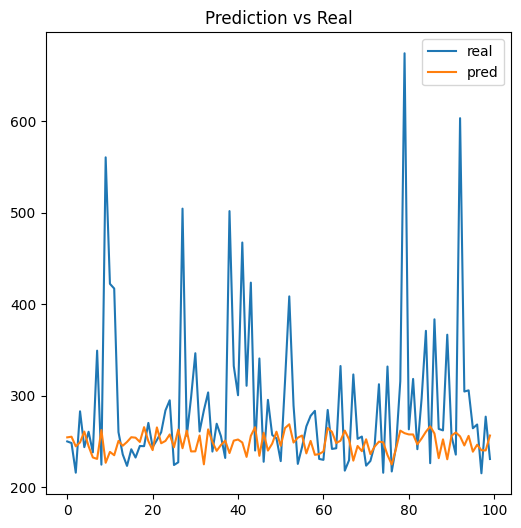

In [68]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


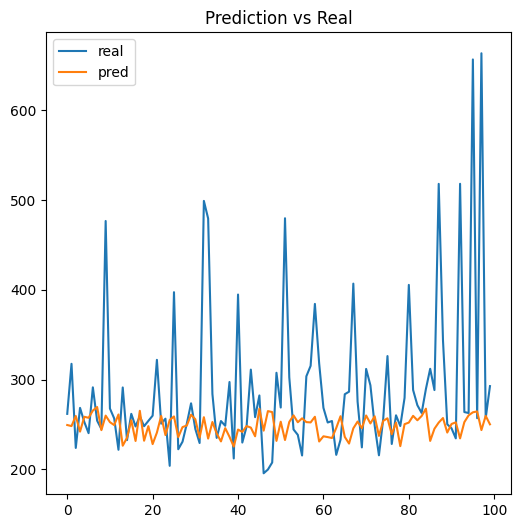

In [69]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


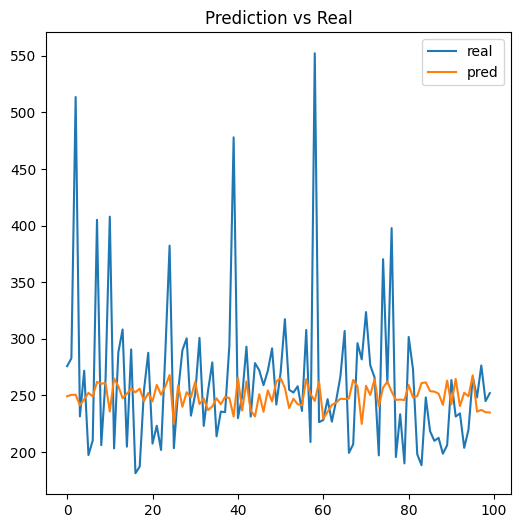

In [70]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


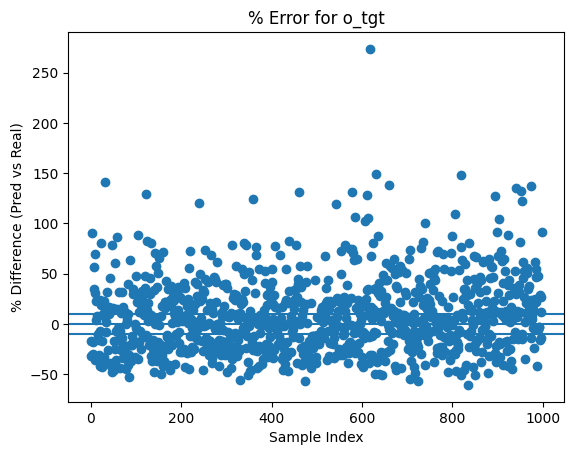

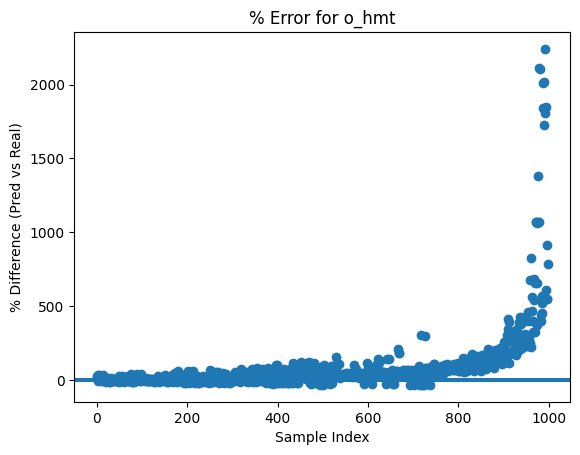

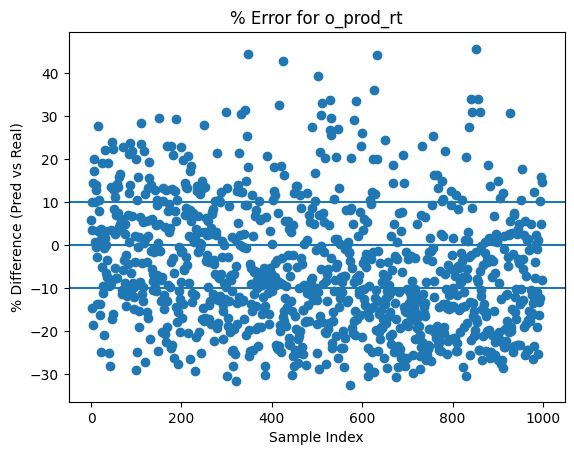

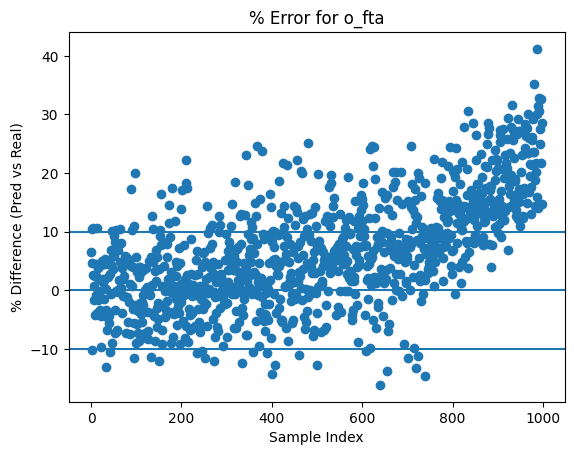

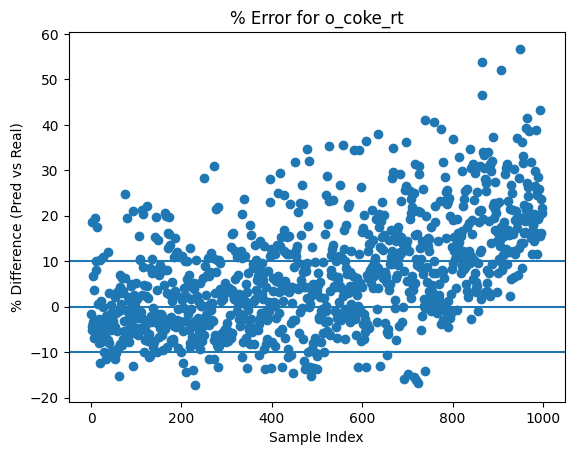

In [71]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


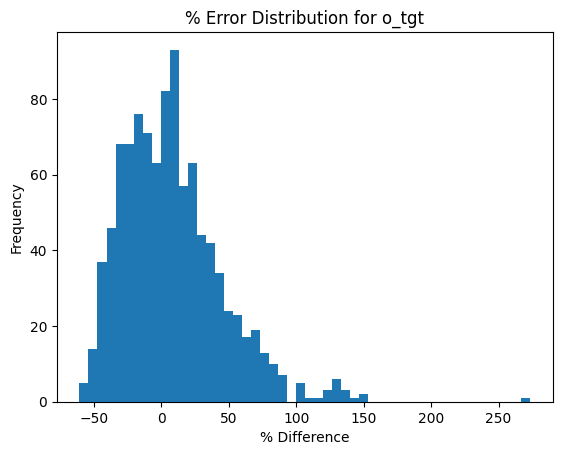

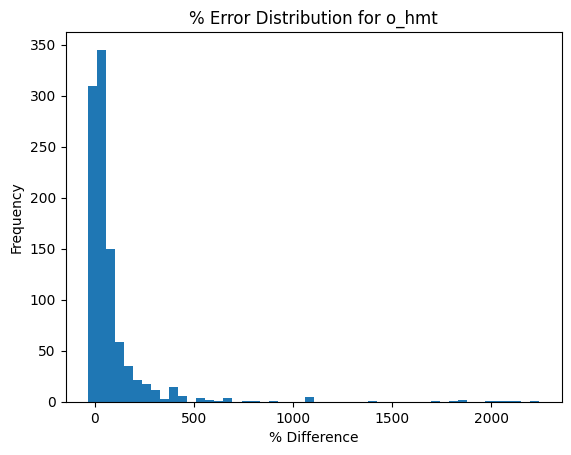

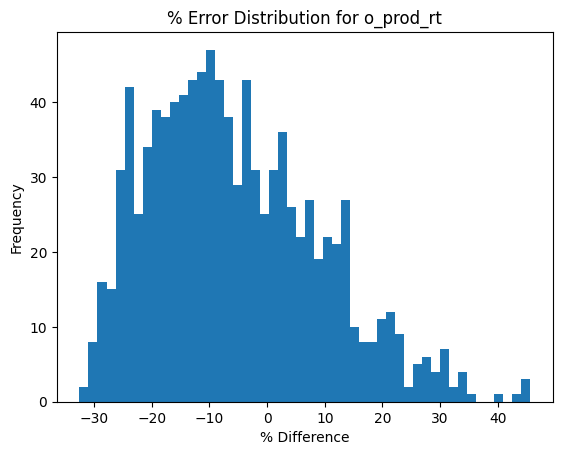

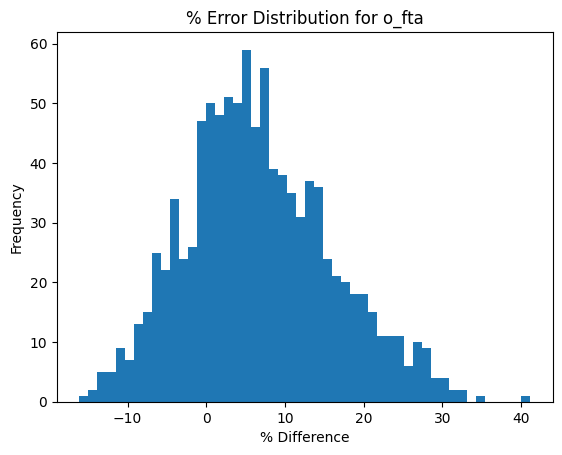

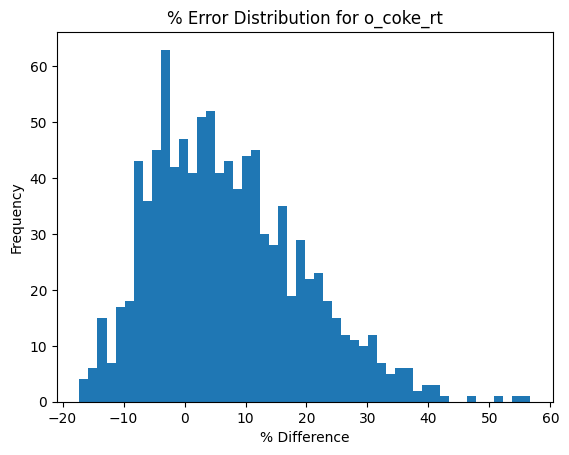

In [72]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [73]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


o_tgt
  within 5% : 11.11111111111111
  within 10%: 23.223223223223226
o_hmt
  within 5% : 10.01001001001001
  within 10%: 19.91991991991992
o_prod_rt
  within 5% : 20.02002002002002
  within 10%: 39.83983983983984
o_fta
  within 5% : 36.53653653653654
  within 10%: 64.46446446446447
o_coke_rt
  within 5% : 32.63263263263263
  within 10%: 57.95795795795796


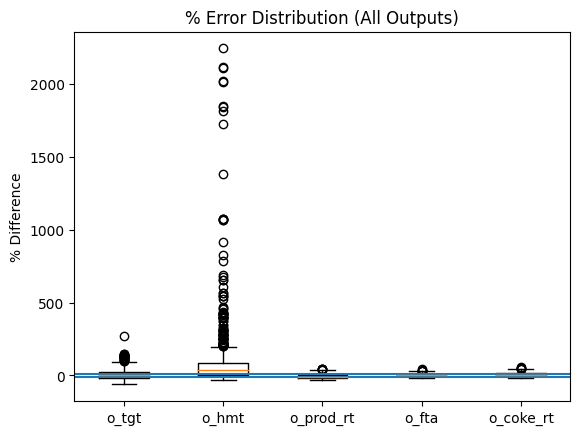

In [74]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


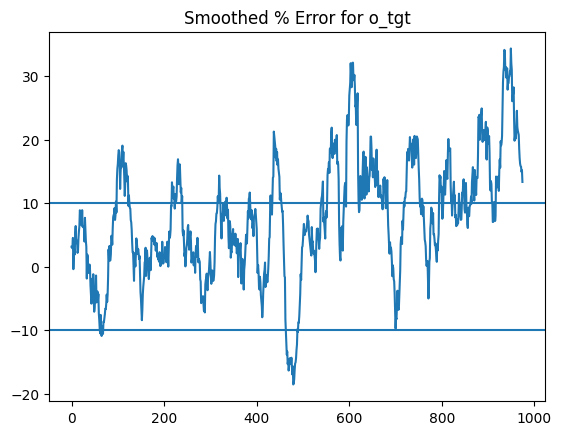

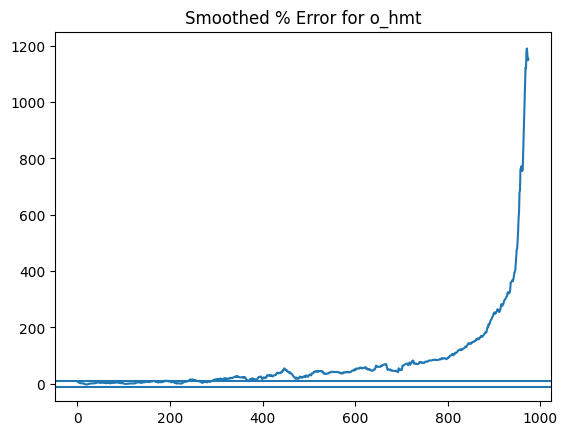

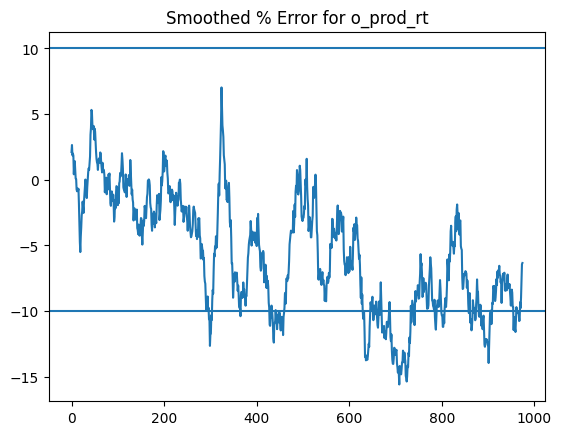

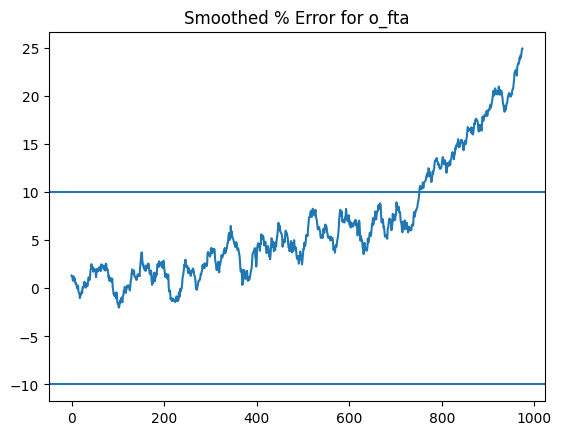

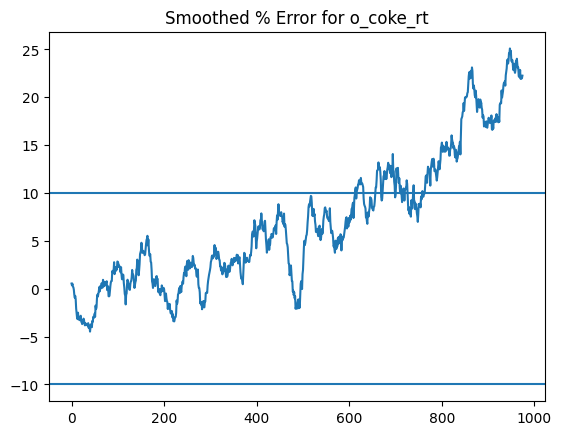

In [75]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


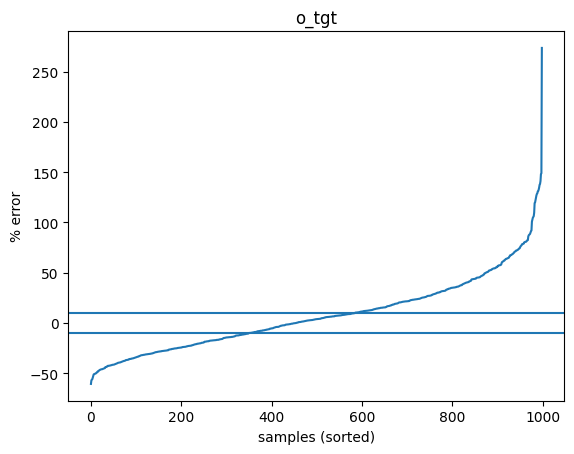

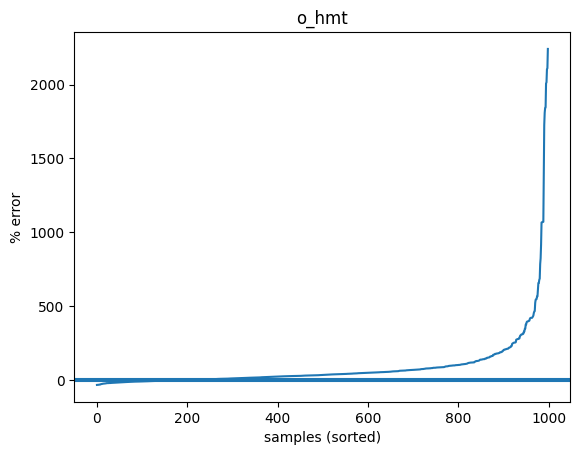

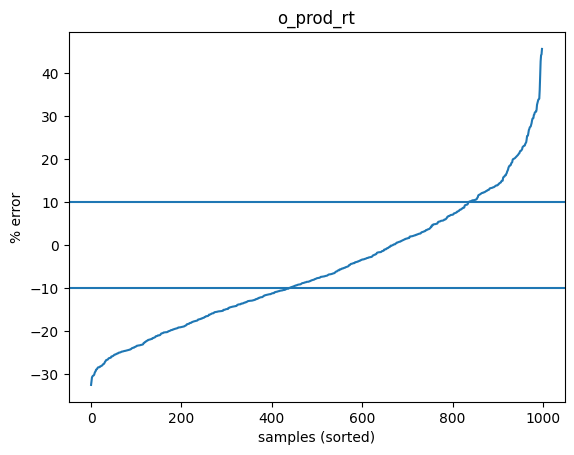

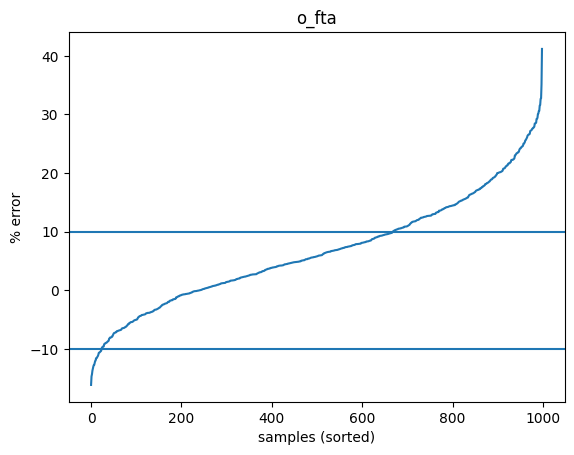

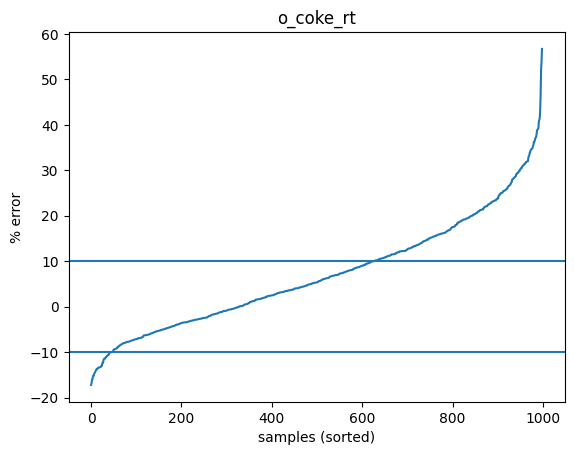

In [76]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()



## Compare effect of switch on coke rate


In [77]:

len( coke_rate_pred_vals_for_ON_OFF )


999

In [78]:

## coke_rate_pred_vals_for_ON_OFF


In [79]:

coke_rate_pred_vals_for_ON_OFF_tr = torch.tensor(coke_rate_pred_vals_for_ON_OFF)


In [80]:

mean_val = coke_rate_pred_vals_for_ON_OFF_tr.mean()

print(mean_val)



tensor(439.5511)


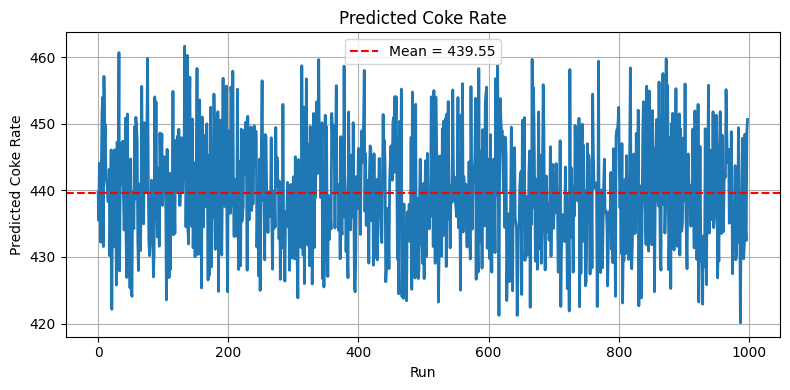

In [81]:


plt.figure(figsize=(8,4))
plt.plot(coke_rate_pred_vals_for_ON_OFF_tr.cpu().numpy(), linewidth=2)
plt.axhline(coke_rate_pred_vals_for_ON_OFF_tr.mean().item(),
            color='red', linestyle='--',
            label=f"Mean = {coke_rate_pred_vals_for_ON_OFF_tr.mean():.2f}")

plt.xlabel("Run")
plt.ylabel("Predicted Coke Rate")
plt.title("Predicted Coke Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


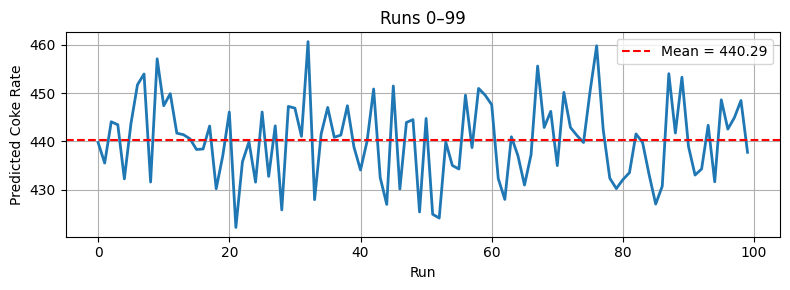

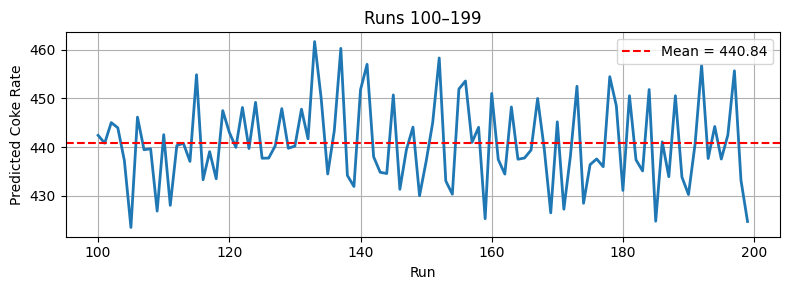

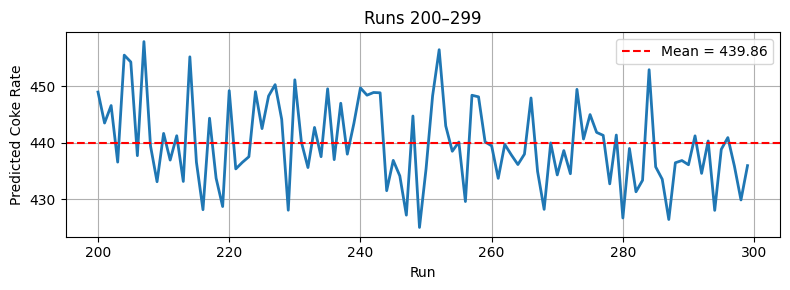

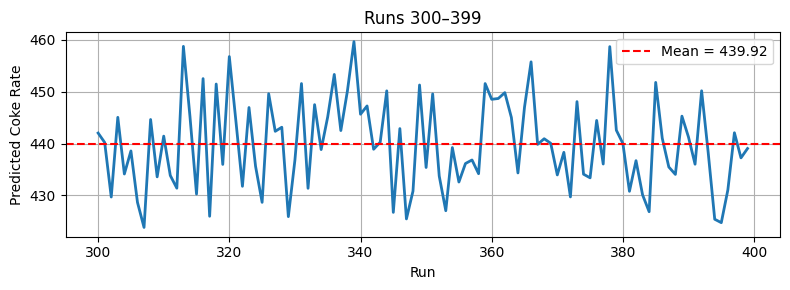

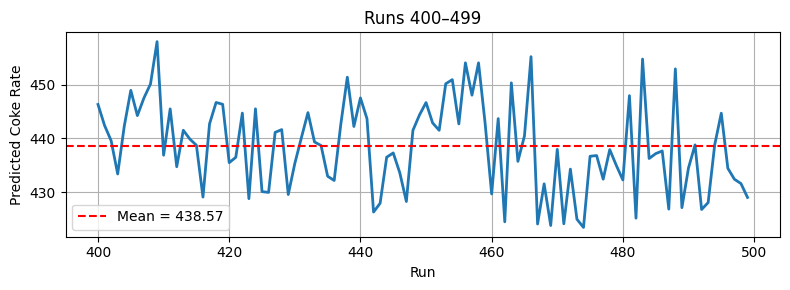

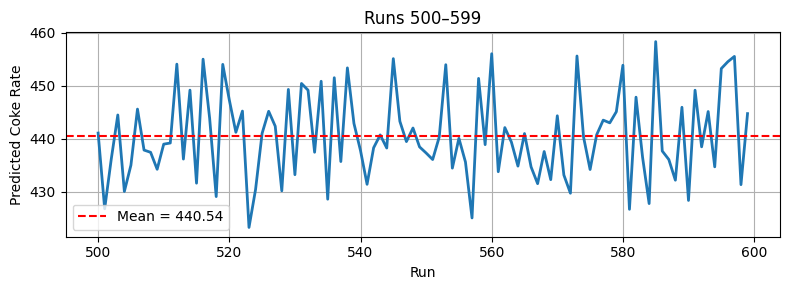

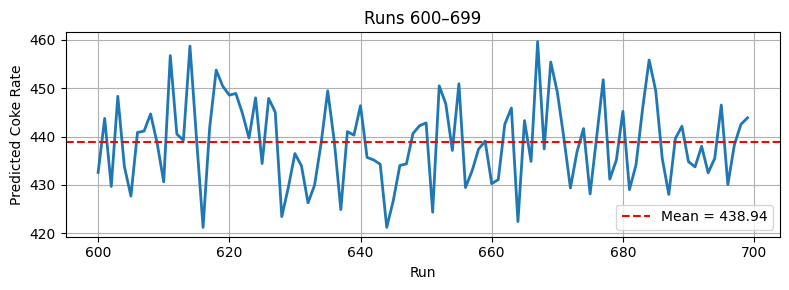

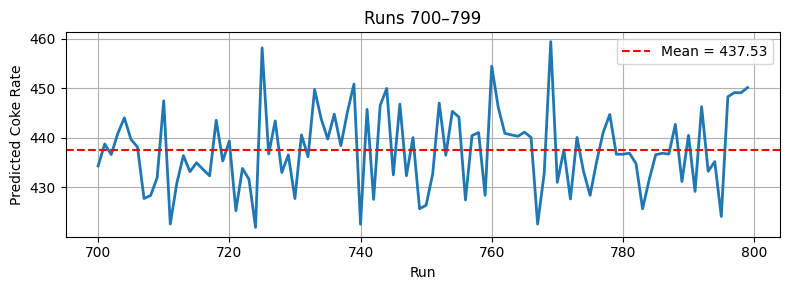

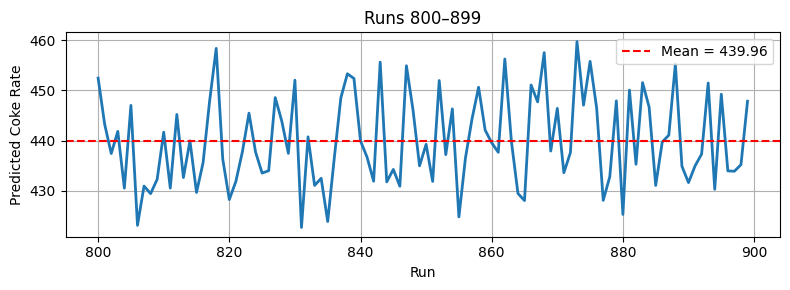

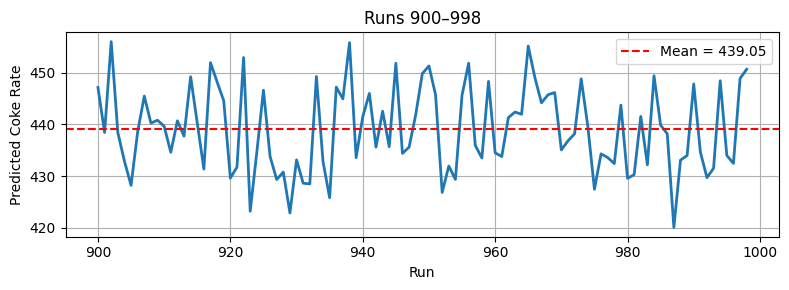

In [82]:

import matplotlib.pyplot as plt
import numpy as np

vals = coke_rate_pred_vals_for_ON_OFF_tr.cpu().numpy()

chunk_size = 100

for start in range(0, len(vals), chunk_size):
    end = min(start + chunk_size, len(vals))

    plt.figure(figsize=(8,3))
    plt.plot(np.arange(start, end), vals[start:end], linewidth=2)
    plt.axhline(vals[start:end].mean(),
                color='red', linestyle='--',
                label=f"Mean = {vals[start:end].mean():.2f}")

    plt.title(f"Runs {start}–{end-1}")
    plt.xlabel("Run")
    plt.ylabel("Predicted Coke Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


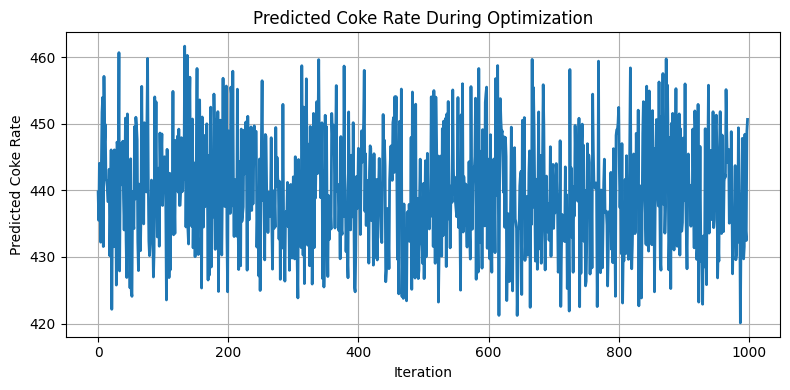

In [83]:


plt.figure(figsize=(8,4))

plt.plot(
    coke_rate_pred_vals_for_ON_OFF_tr.cpu().numpy(),
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Predicted Coke Rate")
plt.title("Predicted Coke Rate During Optimization")
plt.grid(True)

plt.tight_layout()
plt.show()


In [87]:



## torch.save(coke_rate_pred_vals_for_ON_OFF_tr.cpu(), "coke_rate_ON.pt")


## or


torch.save(coke_rate_pred_vals_for_ON_OFF_tr.cpu(), "coke_rate_OFF.pt")



## After running OFF and ON cases, you merge data from both cases


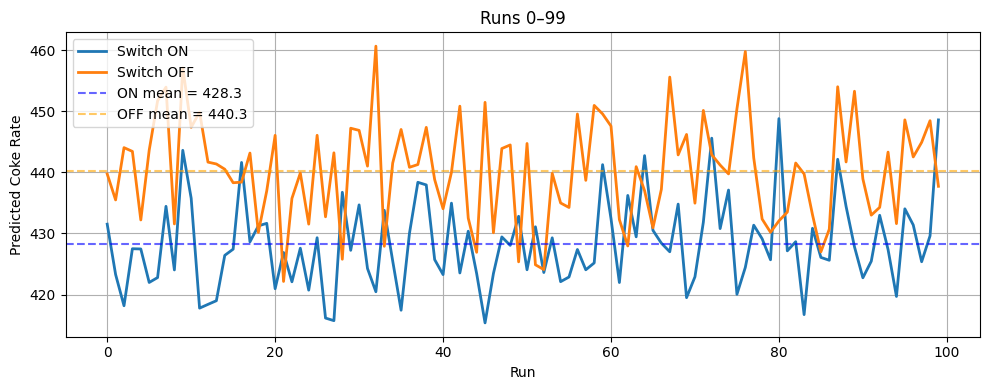

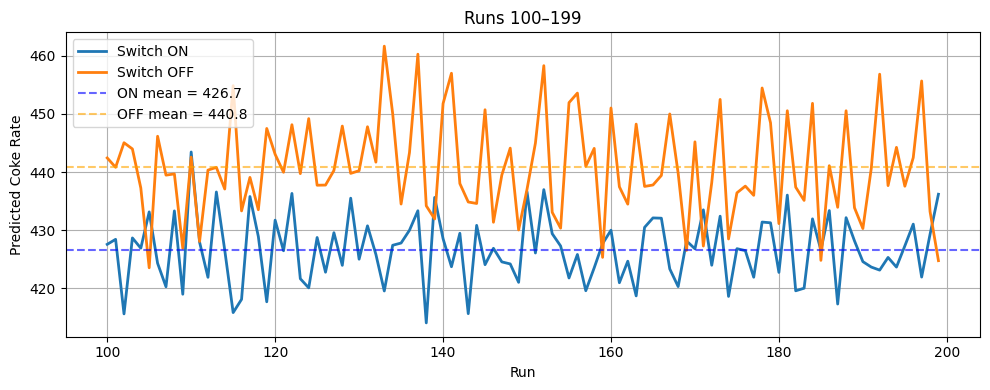

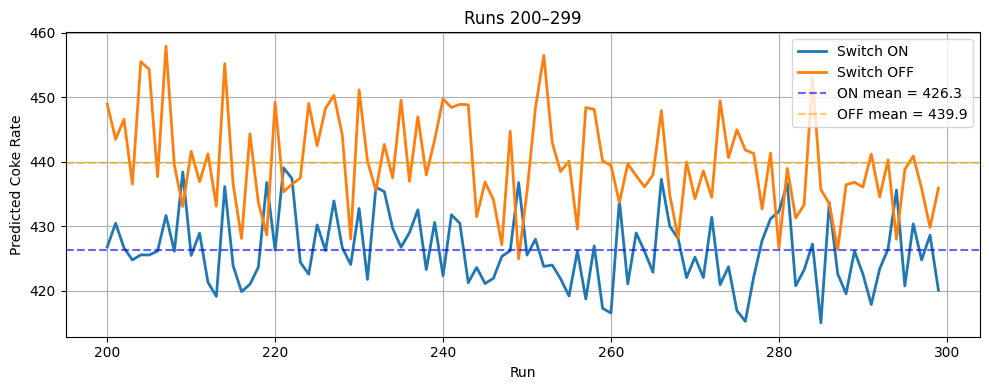

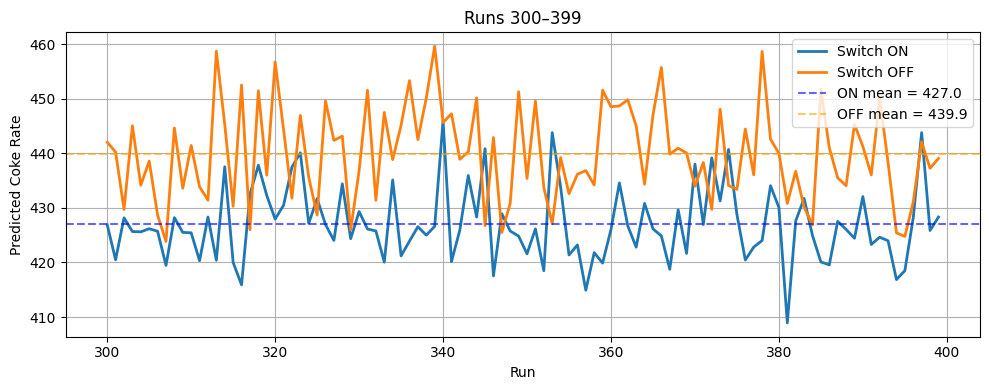

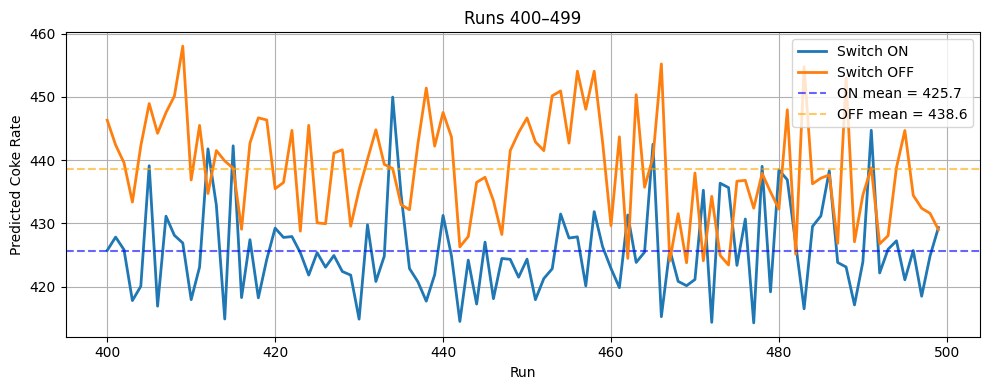

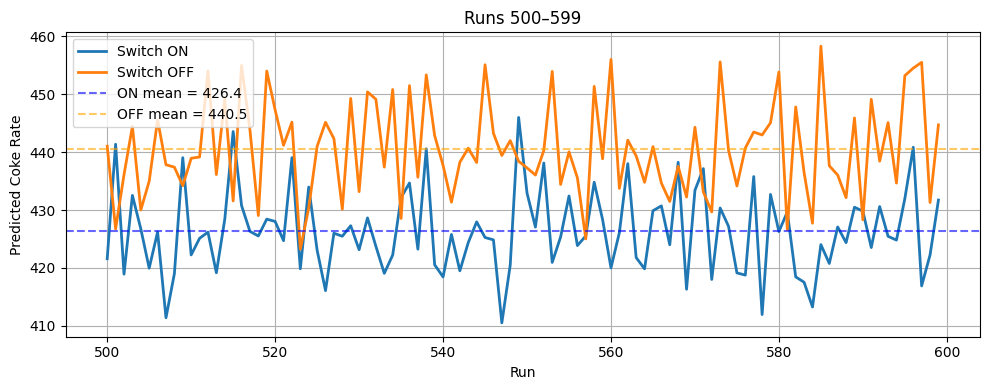

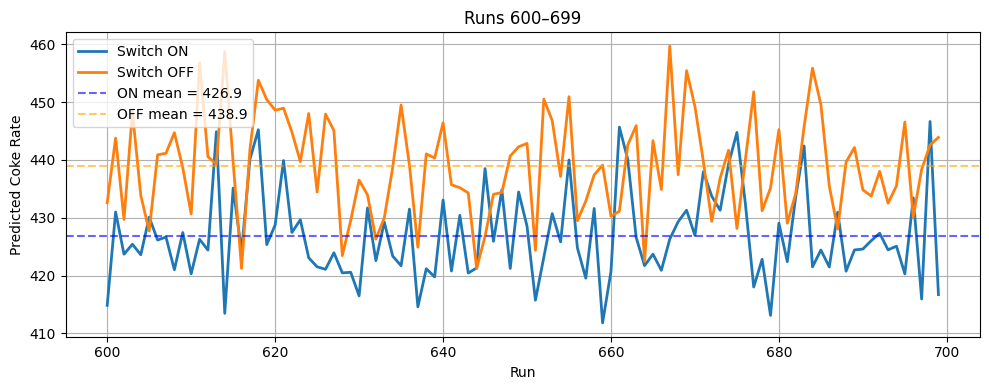

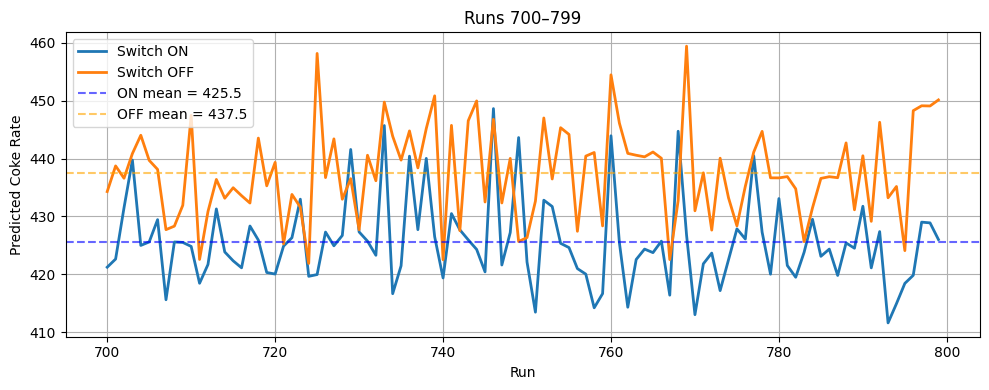

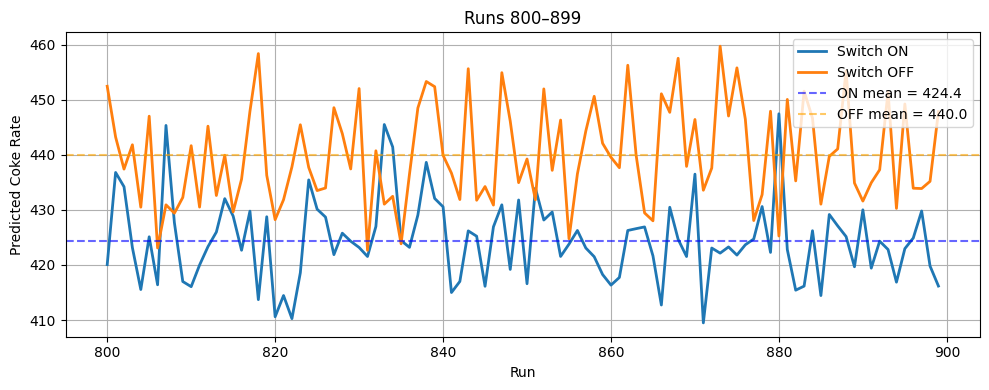

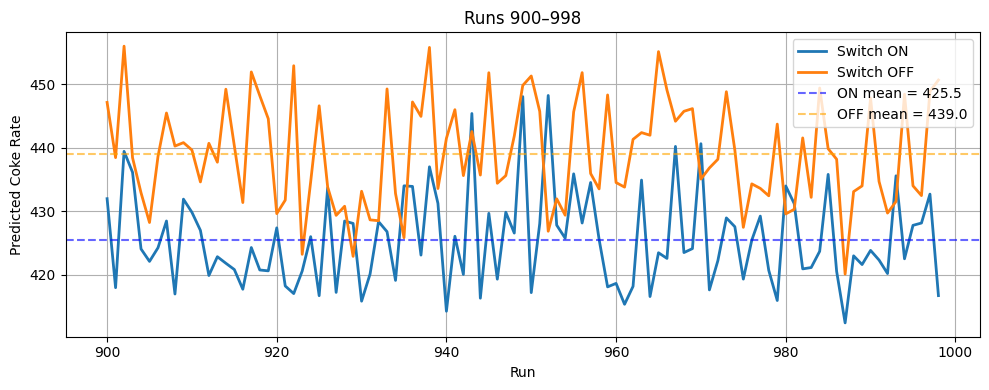

In [88]:

import torch
import matplotlib.pyplot as plt
import numpy as np

on  = torch.load("coke_rate_ON.pt").numpy()
off = torch.load("coke_rate_OFF.pt").numpy()

chunk_size = 100

for start in range(0, min(len(on), len(off)), chunk_size):
    end = min(start + chunk_size, len(on), len(off))

    plt.figure(figsize=(10,4))

    plt.plot(np.arange(start, end), on[start:end],
             label="Switch ON", linewidth=2)

    plt.plot(np.arange(start, end), off[start:end],
             label="Switch OFF", linewidth=2)

    plt.axhline(on[start:end].mean(),
                color='blue', linestyle='--',
                alpha=0.6,
                label=f'ON mean = {on[start:end].mean():.1f}')

    plt.axhline(off[start:end].mean(),
                color='orange', linestyle='--',
                alpha=0.6,
                label=f'OFF mean = {off[start:end].mean():.1f}')

    plt.title(f"Runs {start}–{end-1}")
    plt.xlabel("Run")
    plt.ylabel("Predicted Coke Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 